# Machine Learning Project — Credit Card Fraud Detection

## Project Overview

Credit card fraud detection is a **binary classification** problem in which each transaction must be classified as either legitimate or fraudulent.

This project uses **Gaussian Naive Bayes**, a probabilistic supervised learning algorithm, as the primary model. The notebook focuses on understanding the model and studying the effect of preprocessing techniques on an imbalanced classification problem.

## Problem Statement

Build a machine learning model that can distinguish between legitimate and fraudulent credit card transactions.

The key challenge is **severe class imbalance**: fraudulent transactions represent only a very small fraction of the dataset. Therefore, the project evaluates whether Gaussian Naive Bayes can identify the minority fraud class effectively while controlling false-positive predictions.

## Initial Data Inspection

The first steps of the project are to:

1. Load the dataset.
2. Inspect the available records and features.
3. Check for missing values.
4. Examine the target-class distribution.
5. Inspect feature correlations.

These steps help verify data quality and identify issues that may affect model training.

In [117]:
import kagglehub
import os
import pandas as pd 
import warnings
warnings.filterwarnings(action='ignore')
# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Path to dataset files: /home/solow/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


In [118]:
file=os.listdir(path=path)

In [119]:
file=path+'/'+file[0]
df=pd.read_csv(file)

## Dataset Description

The dataset contains **284,807 transactions and 31 columns**.

The main columns are:

- `Time` — elapsed time between transactions.
- `V1`–`V28` — anonymized numerical features obtained through PCA transformation.
- `Amount` — transaction amount.
- `Class` — target variable, where `0` is legitimate and `1` is fraud.

The target column `Class` is separated from the input features before model training.

In [120]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [121]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [122]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

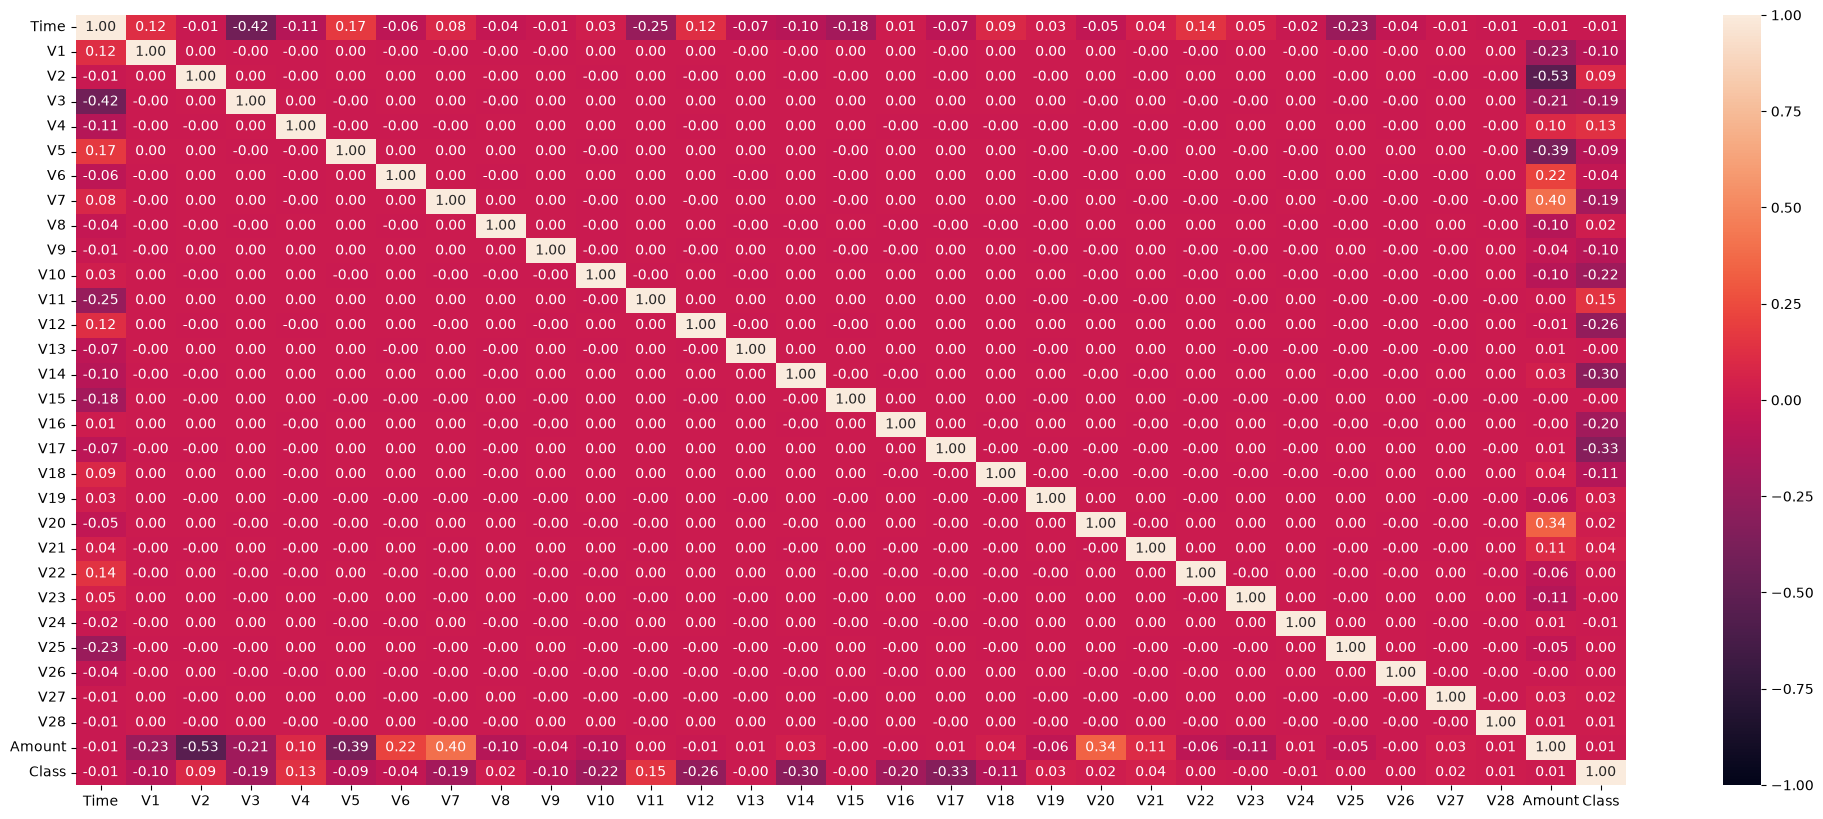

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(25,10))
sns.heatmap(df.corr(),vmax=1,vmin=-1,annot=True,fmt='.2f')
plt.show()

In [124]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report , accuracy_score
from sklearn.preprocessing import StandardScaler

## Feature and Target Separation

The `Class` column is used as the target variable, while the remaining model features are used as inputs.

The `Time` feature is excluded from the modelling data in this project. The resulting feature matrix is used for the subsequent train/test split and experiments.

In [125]:
x=df.drop(columns=['Class','Time'])
y=df['Class']

## Train/Test Split

The data is divided into training and testing subsets using an **80/20 split**.

`stratify=y` is used to preserve the proportion of legitimate and fraudulent transactions in both subsets. This is especially important because the fraud class is extremely small.

The test set is kept separate throughout the preprocessing experiments so that it can provide an unbiased evaluation of the trained models.

In [126]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=24,test_size=.2,stratify=y)

# Gaussian Naive Bayes for Credit Card Fraud Detection

This project applies **Gaussian Naive Bayes (GaussianNB)** to a highly imbalanced credit card fraud detection dataset.

The main objective is to understand how Gaussian Naive Bayes performs under different preprocessing strategies:

- Baseline Gaussian Naive Bayes
- Gaussian Naive Bayes with feature scaling
- Gaussian Naive Bayes with SMOTE
- Gaussian Naive Bayes with both SMOTE and feature scaling

A Logistic Regression model is also used as a secondary comparison model.

Because fraud is the minority class, the evaluation focuses on **precision, recall, F1-score, ROC-AUC, and PR-AUC**, rather than relying only on accuracy.

In [ ]:
model=GaussianNB()
model_nb_scaled = GaussianNB()
model_nb_smote = GaussianNB()
model_nb_smote_scaled = GaussianNB()

## exp 1.1 without scaling

In [ ]:
model.fit(x_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[227451., 394.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[1.,0.]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,6.264e-05
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](29,)","['V1','V2','V3',...,'V27','V28','Amount']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,29
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 29)","[[ 0.01, -0.01, 0.01,..., 0. , -0. , 88.46], [ -4.63, 3.61, -6.99,..., 0.16, 0.06,115.44]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 29)","[[ 3.71, 2.65, 2.13,..., 0.16, 0.1 ,62630.68], [ 45.82, 18.66, 49.57,..., 1.92, 0.29,65877.71]]"


In [128]:
prediction=model.predict(x_test)

In [129]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.82      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.90      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [130]:
prediction_train=model.predict(x_train)
print(classification_report(y_train,prediction_train))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    227451
           1       0.06      0.83      0.11       394

    accuracy                           0.98    227845
   macro avg       0.53      0.91      0.55    227845
weighted avg       1.00      0.98      0.99    227845



### here we have more data for the 0 class , class distribution is not balance

### exp 1.2 with scaling

In [131]:
ss=StandardScaler()
x_train_scale=ss.fit_transform(x_train)
x_test_scale=ss.transform(x_test)

In [132]:
model_nb_scaled.fit(x_train_scale,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[227451., 394.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[1.,0.]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,29
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 29)","[[ 0. ,-0. , 0.01,...,-0. ,-0. ,-0. ], [-2.37, 2.2 ,-4.61,..., 0.39, 0.18, 0.11]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 29)","[[ 0.97, 0.98, 0.93,..., 0.98, 1. , 1. ], [12.01, 6.91,21.55,...,11.94, 2.79, 1.05]]"


In [133]:
prediction=model_nb_scaled.predict(x_test_scale)
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.82      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.90      0.55     56962
weighted avg       1.00      0.98      0.99     56962



### exp 1.3 with Smote

In [134]:
from imblearn.over_sampling import SMOTE
sm=SMOTE(sampling_strategy='auto',random_state=22)
x_train_balance,y_train_balance=sm.fit_resample(x_train,y_train)

In [135]:
model_nb_smote.fit(x_train_balance,y_train_balance)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[227451.,227451.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.5,0.5]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,6.193e-05
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](29,)","['V1','V2','V3',...,'V27','V28','Amount']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,29
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 29)","[[ 0.01, -0.01, 0.01,..., 0. , -0. , 88.46], [ -4.48, 3.64, -6.94,..., 0.19, 0.07,113.2 ]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 29)","[[ 3.71, 2.65, 2.13,..., 0.16, 0.1 ,62630.68], [ 44.11, 16.73, 47.54,..., 1.71, 0.22,60926.61]]"


In [136]:
prediction=model_nb_smote.predict(x_test)
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.83      0.10        98

    accuracy                           0.98     56962
   macro avg       0.53      0.90      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [137]:
prediction_scale=model_nb_smote.predict(x_test_scale)
print(classification_report(y_test,prediction_scale))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.03      0.83      0.06        98

    accuracy                           0.96     56962
   macro avg       0.52      0.89      0.52     56962
weighted avg       1.00      0.96      0.98     56962



### exp 1.4 somte+scaling

In [138]:
x_train_balance_scale,y_train_balance_scale=sm.fit_resample(x_train_scale,y_train)

In [139]:
model_nb_smote_scaled.fit(x_train_balance_scale,y_train_balance_scale)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[227451.,227451.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.5,0.5]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,4.819e-08
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,29
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 29)","[[ 0. ,-0. , 0.01,...,-0. ,-0. ,-0. ], [-2.28, 2.25,-4.57,..., 0.43, 0.24, 0.04]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 29)","[[ 0.97, 0.98, 0.93,..., 0.98, 1. , 1. ], [11.81, 6.18,21.27,...,10.98, 2.32, 0.67]]"


In [140]:
prediction_balance_scale=model_nb_smote_scaled.predict(x_test_scale)
print(classification_report(y_test,prediction_balance_scale))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.83      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.90      0.55     56962
weighted avg       1.00      0.98      0.99     56962



## Secondary Model Comparison — Logistic Regression

Logistic Regression is included as a **secondary baseline** rather than as the main focus of this project.

The purpose is to provide context for Gaussian Naive Bayes performance. Both scaled and unscaled training/testing representations are kept consistent so that the comparison is methodologically valid.

In [146]:
from sklearn.linear_model import LogisticRegression
model_lr_scale=LogisticRegression()
model_lr=LogisticRegression()
model_lr_scale.fit(x_train_balance_scale,y_train_balance_scale)
model_lr.fit(x_train_balance,y_train_balance)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [147]:
prediction_lr_scale=model_lr_scale.predict(x_test_scale)
prediction_lr_uncale=model_lr.predict(x_test)
print(classification_report(y_test,prediction_lr_scale))
print('*'*55)
print(classification_report(y_test,prediction_lr_uncale))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.90      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.98      0.99     56962

*******************************************************
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.08      0.88      0.15        98

    accuracy                           0.98     56962
   macro avg       0.54      0.93      0.57     56962
weighted avg       1.00      0.98      0.99     56962



## ROC-AUC Evaluation

ROC-AUC measures how well the model separates fraudulent and legitimate transactions across different classification thresholds.

The model's predicted fraud probabilities are calculated from the **correctly scaled test data**, matching the representation used during training.

Because this dataset is highly imbalanced, ROC-AUC is reported together with Precision-Recall metrics rather than being used as the only performance measure.

In [ ]:
from sklearn.metrics import roc_auc_score
y_prob=model_nb_smote_scaled.predict_proba(x_test_scale)[:, 1]
roc_auc=roc_auc_score(y_test, y_prob)
print("ROC-AUC:",roc_auc)

ROC-AUC: 0.9437826234883374


## Precision-Recall AUC

The Precision-Recall curve shows the trade-off between precision and recall across different classification thresholds.

**PR-AUC is particularly useful for this project because fraud is a very rare positive class.** It provides a more focused view of how effectively the model identifies fraud while limiting false-positive predictions.

The final PR-AUC is calculated from the same correctly generated fraud probabilities used for the ROC-AUC evaluation.

In [149]:
from sklearn.metrics import precision_recall_curve, auc
precision,recall,thresholds = precision_recall_curve(y_test,y_prob)
pr_auc=auc(recall, precision)
print("PR-AUC:", pr_auc)

PR-AUC: 0.4336803664593519


# Final Observations

This project demonstrates the application of **Gaussian Naive Bayes to an imbalanced binary classification problem** and investigates the effects of scaling and SMOTE.

The main lessons from the experiments are:

- Accuracy should not be treated as the primary metric for this fraud-detection dataset.
- Fraud-class precision, recall, and F1-score provide more useful information.
- SMOTE can increase the model's ability to detect minority-class examples, but improved recall does not necessarily mean improved overall F1-score.
- Feature scaling has limited impact on Gaussian Naive Bayes in this experiment compared with algorithms that depend strongly on feature magnitude.
- ROC-AUC and especially PR-AUC provide threshold-independent views of model performance.
- Logistic Regression provides a useful secondary baseline for comparison.

For this starter project, the main goal is not to build a production-ready fraud detector, but to understand **Gaussian Naive Bayes, class imbalance, preprocessing, and appropriate model evaluation**.